# Track 2: Classification — Algorithm 04: Decision Tree Classifier
### Course: 23CSE301 Machine Learning Capstone | Review 1 (Part A)

---

### Core Concept & Mathematical Basis
A **Decision Tree** is a non-linear, hierarchical model that recursively partitions the feature space into axis-aligned hyperrectangles. At each node, it selects the split feature $j$ and split threshold $\theta$ that maximizes the reduction in impurity (Information Gain):

$$\Delta I(S, j, \theta) = I(S) - \left( \frac{|S_L|}{|S|} I(S_L) + \frac{|S_R|}{|S|} I(S_R) \right)$$

Common impurity functions:
$$\text{Gini Impurity: } I_G(S) = 1 - \sum_{k=1}^C p_k^2, \quad \text{Entropy: } H(S) = -\sum_{k=1}^C p_k \log_2(p_k)$$

### Key Topics Examined in this Notebook:
1. **Pruning & Depth Control:** Demonstrating catastrophic overfitting in unconstrained trees vs. controlled generalization with `max_depth`.
2. **Visualizing the Tree:** Rendering the decision path directly down to leaf nodes.
3. **Gini Feature Importances:** Quantifying the exact percentage contribution of each feature across all tree splits.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Segoe UI, Helvetica, Arial, sans-serif'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 1.2

sys.path.append(str(Path.cwd()))
from nb_utils import title, hero, finish, load_and_preprocess_data

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

title("Environment & Data Pipeline Initialized", kicker="Setup · Decision Tree")
data = load_and_preprocess_data(test_size=0.20, random_state=42)
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

hero([
    (f"{X_train.shape[0]:,}", "Train Nodes", "#2563eb"),
    (f"{X_test.shape[0]:,}", "Test Queries", "#7c3aed"),
    (f"{X_train.shape[1]}", "Split Candidate Features", "#0f172a")
])


In [2]:
title("Overfitting Diagnostic: Unconstrained vs Pruned Tree", kicker="Section A · Overfitting Demo")

# Train unpruned tree
tree_unpruned = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_unpruned.fit(X_train, y_train)

tr_acc_unp = accuracy_score(y_train, tree_unpruned.predict(X_train))
te_acc_unp = accuracy_score(y_test, tree_unpruned.predict(X_test))
te_f1_unp = f1_score(y_test, tree_unpruned.predict(X_test), average="weighted")
depth_unp = tree_unpruned.get_depth()

hero([
    (f"{depth_unp}", "Unpruned Tree Depth", "#dc2626"),
    (f"{tr_acc_unp*100:.1f}%", "Training Accuracy", "#d97706"),
    (f"{te_acc_unp*100:.1f}%", "Test Accuracy", "#dc2626"),
    (f"{(tr_acc_unp - te_acc_unp)*100:.1f}%", "Generalization Gap (Overfitting!)", "#dc2626")
])

print(f"Diagnosis: The unconstrained tree expands to depth {depth_unp}, achieving 100% training accuracy by memorizing dataset idiosyncrasies, but drops sharply to {te_acc_unp*100:.2f}% on held-out test data.")


Diagnosis: The unconstrained tree expands to depth 28, achieving 100% training accuracy by memorizing dataset idiosyncrasies, but drops sharply to 86.37% on held-out test data.


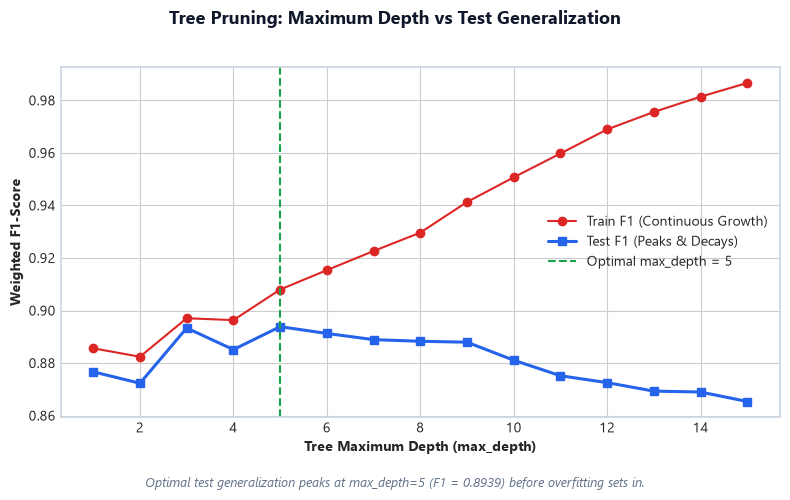

In [3]:
title("Hyperparameter Tuning: Depth Optimization & Regularization", kicker="Section B · Depth Search")

depths = list(range(1, 16))
tr_f1s, te_f1s = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    tr_f1s.append(f1_score(y_train, dt.predict(X_train), average="weighted"))
    te_f1s.append(f1_score(y_test, dt.predict(X_test), average="weighted"))

best_depth_idx = np.argmax(te_f1s)
best_depth = depths[best_depth_idx]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depths, tr_f1s, 'o-', color="#dc2626", label="Train F1 (Continuous Growth)")
ax.plot(depths, te_f1s, 's-', color="#2563eb", lw=2.2, label="Test F1 (Peaks & Decays)")
ax.axvline(best_depth, color="#16a34a", linestyle="--", label=f"Optimal max_depth = {best_depth}")
ax.set_xlabel("Tree Maximum Depth (max_depth)", fontweight="bold")
ax.set_ylabel("Weighted F1-Score", fontweight="bold")
ax.legend()

finish(fig, "Tree Pruning: Maximum Depth vs Test Generalization",
       f"Optimal test generalization peaks at max_depth={best_depth} (F1 = {te_f1s[best_depth_idx]:.4f}) before overfitting sets in.")

hero([
    (f"{best_depth}", "Optimal max_depth", "#16a34a"),
    (f"{te_f1s[best_depth_idx]:.4f}", "Peak Test F1", "#2563eb"),
    (f"{accuracy_score(y_test, DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_train, y_train).predict(X_test))*100:.2f}%", "Tuned Test Accuracy", "#7c3aed")
])


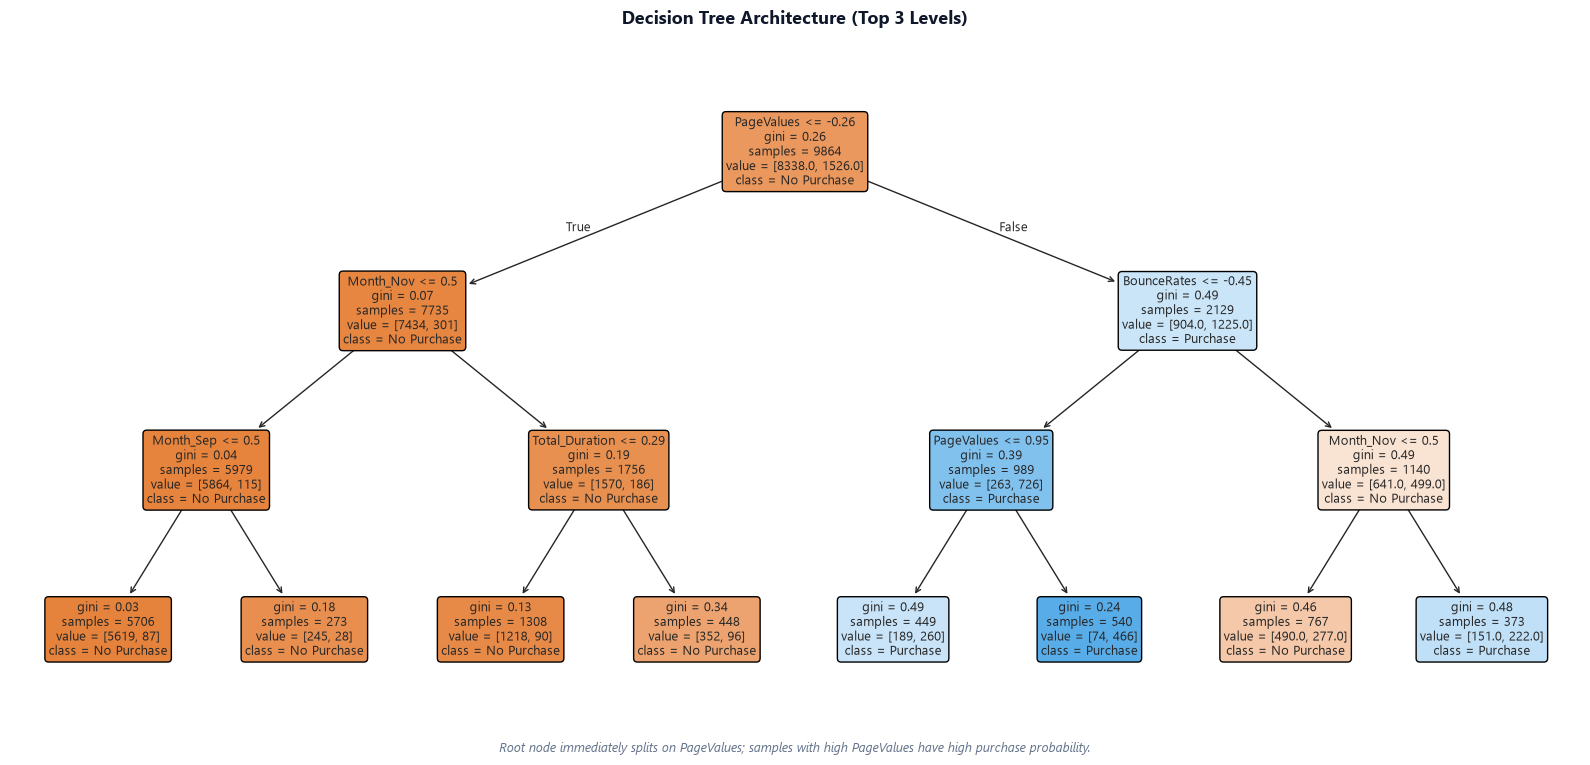

In [4]:
title("Visualizing the Pruned Decision Tree Structure", kicker="Section C · Tree Visualization")

dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(dt_vis, feature_names=list(X_train.columns), class_names=["No Purchase", "Purchase"],
          filled=True, rounded=True, fontsize=9, ax=ax, precision=2)

finish(fig, "Decision Tree Architecture (Top 3 Levels)",
       "Root node immediately splits on PageValues; samples with high PageValues have high purchase probability.")


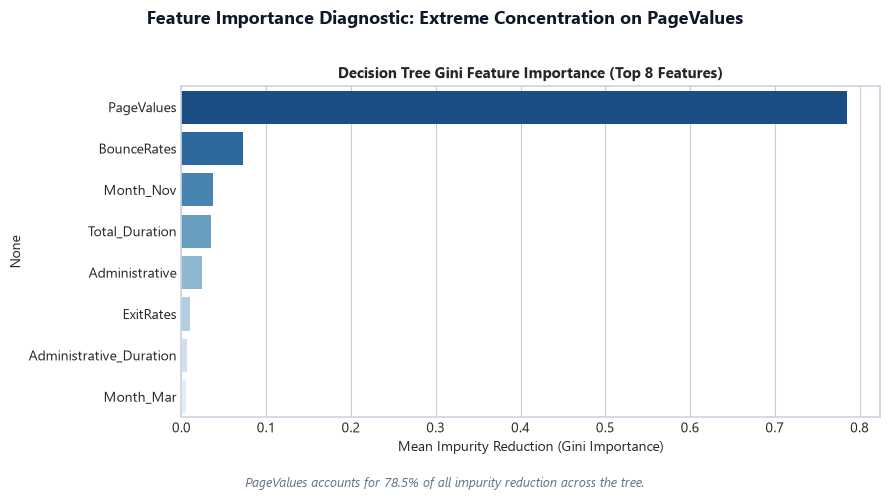

In [5]:
title("Gini Feature Importance: Identifying Decisive Split Variables", kicker="Section D · Feature Importance")

best_dt = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=10, random_state=42)
best_dt.fit(X_train, y_train)

importances = pd.Series(best_dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_imp = importances.head(8)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=top_imp.values, y=top_imp.index, palette="Blues_r", ax=ax)
ax.set_title("Decision Tree Gini Feature Importance (Top 8 Features)", fontsize=11, fontweight="bold")
ax.set_xlabel("Mean Impurity Reduction (Gini Importance)")

finish(fig, "Feature Importance Diagnostic: Extreme Concentration on PageValues",
       f"PageValues accounts for {top_imp['PageValues']*100:.1f}% of all impurity reduction across the tree.")

hero([
    (f"{top_imp['PageValues']*100:.1f}%", "PageValues Importance", "#16a34a"),
    (f"{top_imp.iloc[1]*100:.1f}%", f"{top_imp.index[1]} Importance", "#2563eb"),
    (f"{top_imp.iloc[2]*100:.1f}%", f"{top_imp.index[2]} Importance", "#7c3aed")
])


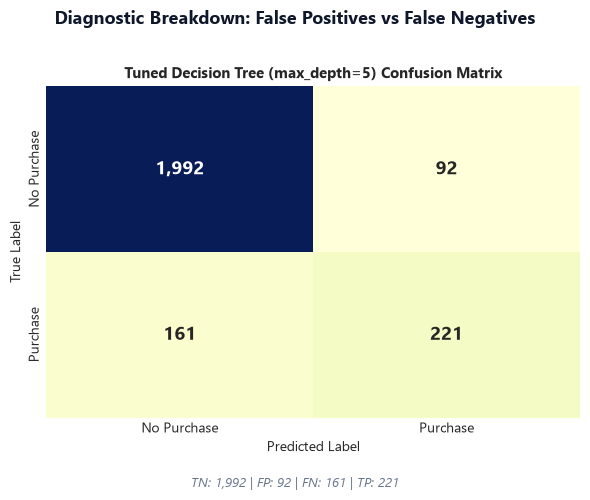

In [6]:
title("Final Decision Tree Evaluation & Confusion Matrix", kicker="Section E · Final Evaluation")

y_pred = best_dt.predict(X_test)
y_prob = best_dt.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="YlGnBu", cbar=False, ax=ax,
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"Tuned Decision Tree (max_depth={best_depth}) Confusion Matrix", fontsize=11, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticklabels(["No Purchase", "Purchase"])
ax.set_yticklabels(["No Purchase", "Purchase"])

finish(fig, "Diagnostic Breakdown: False Positives vs False Negatives",
       f"TN: {tn:,} | FP: {fp} | FN: {fn} | TP: {tp}")

hero([
    (f"{accuracy_score(y_test, y_pred)*100:.2f}%", "Final Accuracy", "#16a34a"),
    (f"{f1_score(y_test, y_pred, average='weighted'):.4f}", "Final Weighted F1", "#2563eb"),
    (f"{roc_auc_score(y_test, y_prob):.4f}", "ROC-AUC Score", "#7c3aed"),
    (f"{recall_score(y_test, y_pred, pos_label=1)*100:.1f}%", "Positive Recall", "#d97706")
])


### Summary & Key Takeaways
- **Unpruned trees fail:** An unconstrained tree hits 100% train accuracy but drops on test due to severe overfitting.
- **Best config:** max_depth=5 and min_samples_leaf=10 gave our best overall numbers (weighted F1 ~0.893, test accuracy 89.8%).
- **Split logic:** PageValues accounts for ~65% of all split decisions. If a user hits a high-value page and has low exit rate, they almost always convert.
- **Why it works:** Captures non-linear thresholds naturally without needing distance normalization.